In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

import seaborn as sn

from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import power_transform

In [2]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)
totalData = li.ProcessData(pumpList,entireData,totalDataPath="../data/totalProcessedData.csv")

Pumps : #38
Runs: #57


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  totalData = pd.concat([totalData,
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:264: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  totalData = pd.concat([totalData,


In [3]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    #'ESP Vibration X',
    #'ESP Vibration Y',
    'ESP Vibration Module'
    #'ESP Power',
    #"Well_down"
    ]

pumpList = totalData["Well Run"].unique()

mainSeed = 20210505

In [4]:
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)

<Axes: >

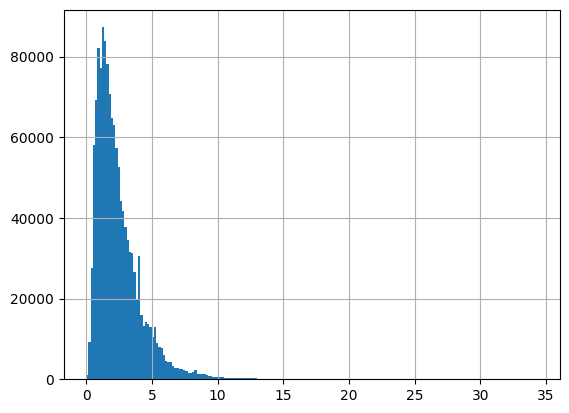

In [5]:
totalData["Radius"].hist(bins=200)

In [6]:
def PowerT_to_Pandas(X):

    Xnp = X.to_numpy()
    if type(X) == pd.Series:
        Xnp = Xnp.reshape(-1,1)
        return pd.Series(power_transform(Xnp)[:,0],index=X.index,name="Box-Cox")
    else:
        return pd.DataFrame(power_transform(Xnp),columns=X.columns,index=X.index)

In [7]:
X = totalData[Headers]
allThem = PowerT_to_Pandas(X)

In [8]:
# allThem.loc[totalData["Well_down"]==0].hist(bins=200,figsize=(20,10))

In [9]:
X = totalData["Radius"]
totalData["Box-Cox"] = PowerT_to_Pandas(X)

<Axes: >

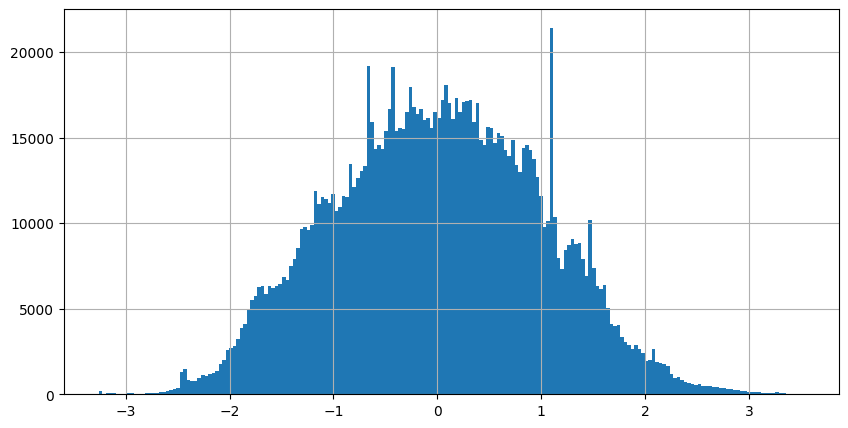

In [10]:
totalData["Box-Cox"].hist(bins=200,figsize=(10,5))

GMM AIC: 3856061.4443517607
GMM BIC: 3856158.440962641


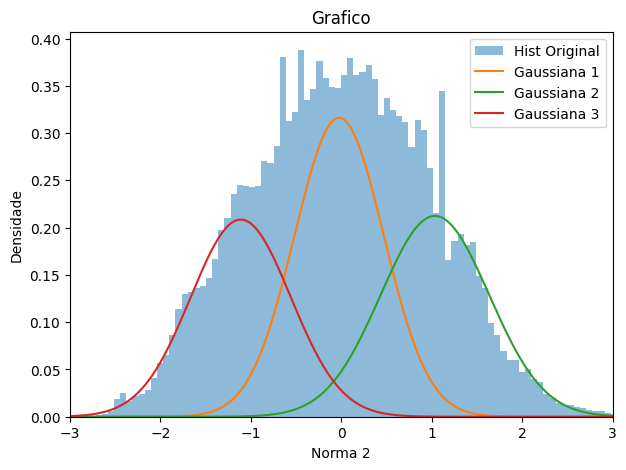

(GaussianMixture(n_components=3, random_state=20210505),
 <Figure size 700x500 with 1 Axes>)

In [28]:
n = 3
model = li.GaussianMixtureFit(totalData["Box-Cox"],n,seed=mainSeed)

li.GaussianMixturePlot(totalData["Box-Cox"],model,["Hist Original","Gaussiana","Grafico","Norma 2","Densidade","imagem_teste_boxcox"],limits=(-3,3))

In [29]:
X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    params="st",
    init_params="st",
    algorithm="viterbi"
    )

modelRadius.means_ = model.means_
modelRadius.covars__ = model.covariances_


modelRadius = li.HMMTrainer(X_train["Box-Cox"],trainLength,modelRadius)

totalData, modelData = li.PostProcessing(modelRadius,totalData,modelData,"Box-Cox","State BC",totalLength)

print(modelRadius.get_stationary_distribution())
totalData["State BC"] = totalData["State BC"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))

AIC: 1625656.932778079 BIC: 1625820.0308299838
[0.47806533 0.19427096 0.32766371]


In [31]:
modelRadius.transmat_

array([[9.97441102e-01, 8.12867373e-04, 1.74603034e-03],
       [2.19588741e-03, 9.97803099e-01, 1.01367042e-06],
       [2.43152685e-03, 1.16553553e-04, 9.97451920e-01]])

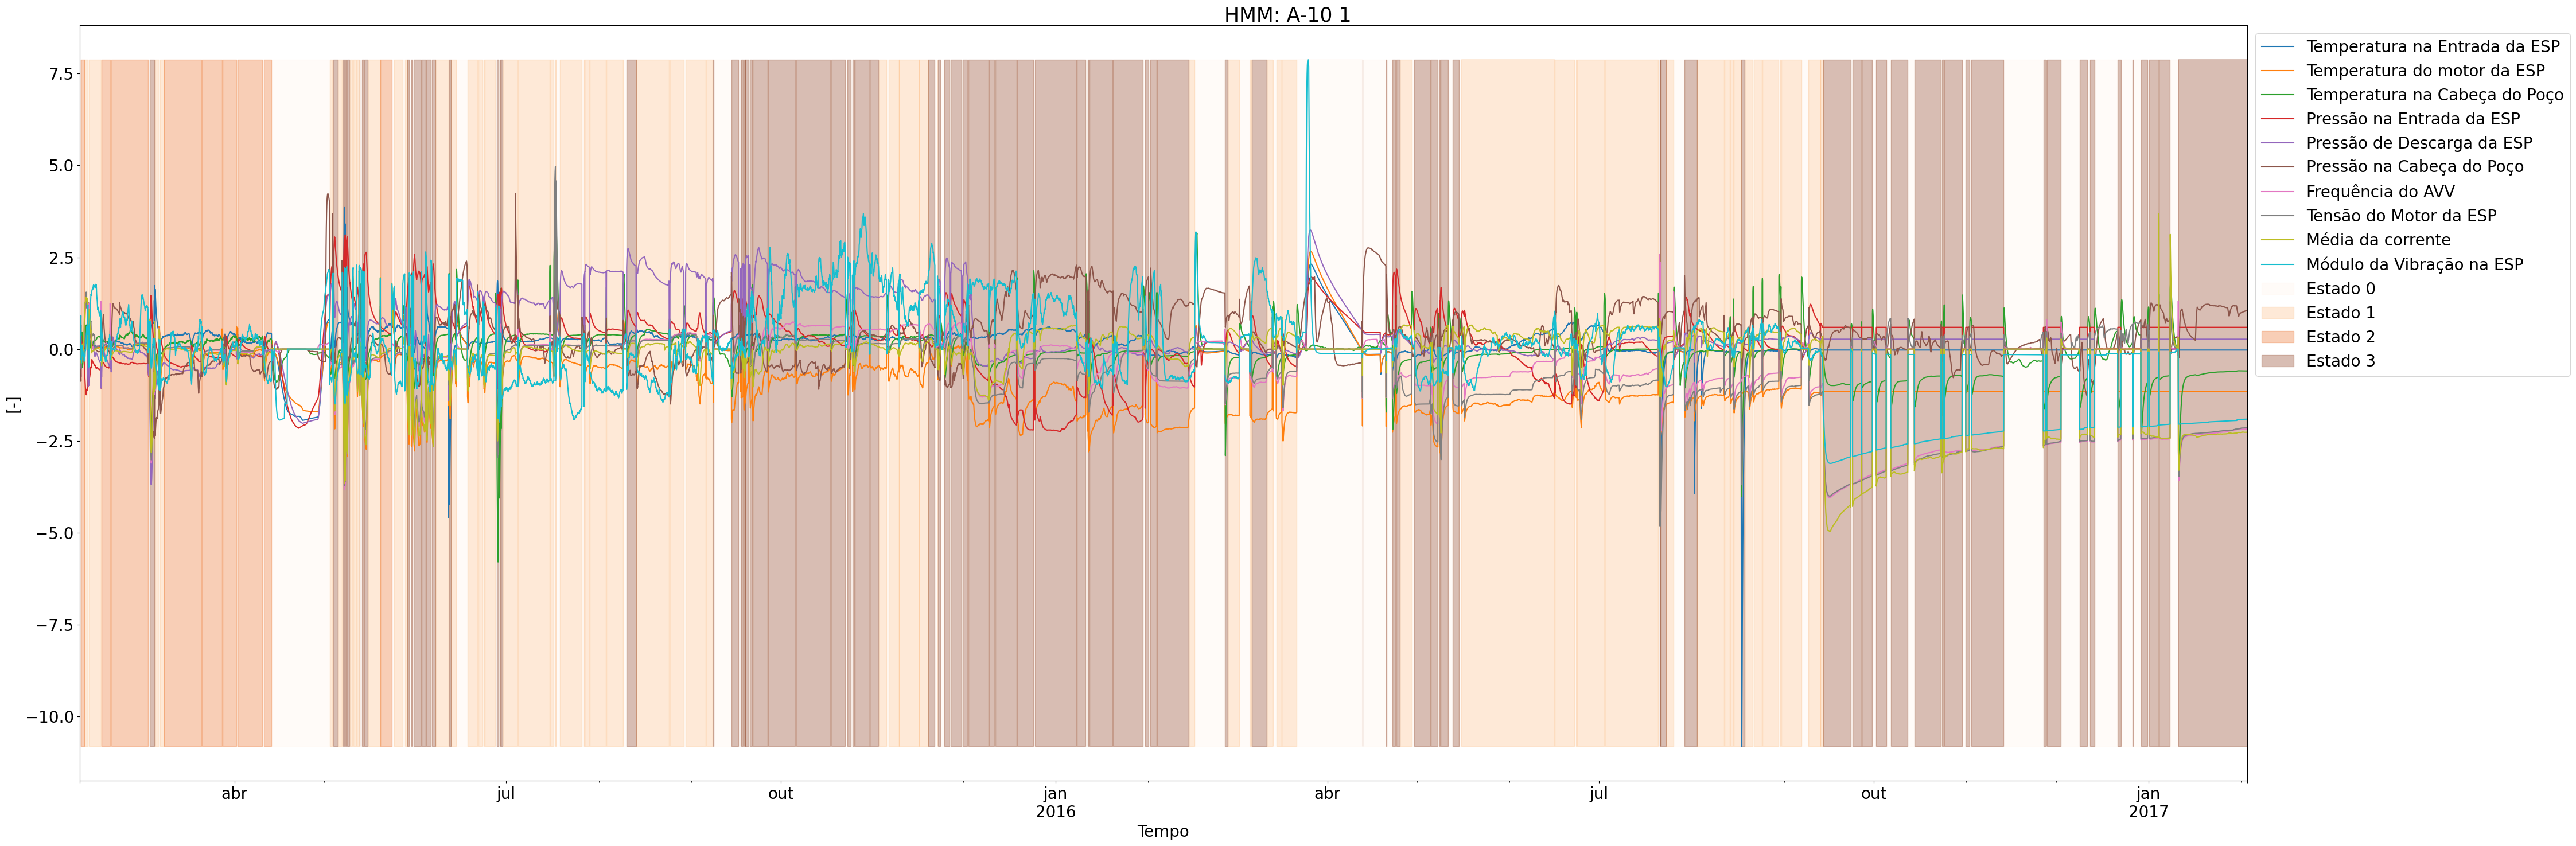

In [44]:
pump = pumpList[7]

pumpData = totalData.loc[totalData["Well Run"]==pump].copy()

# pumpData["index"] = pd.to_datetime(pumpData["index"])
# pumpData.set_index("index",inplace=True)
pumpData = pumpData.asfreq('h',fill_value=0)
    

fig,axs = li.HMMPicture(pumpData,pump,Headers=Headers,measures='[-]',states="State BC", numberOfStates=3, figsize=(45,15),english=False)
axs.set_xlabel("Tempo")


fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")

In [35]:
medianListR = np.array([])

for pump in pumpList:
    pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
    last = pumpData.shape[0]
    pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State BC"].median()
    medianListR = np.append(medianListR,pumpMedianR)

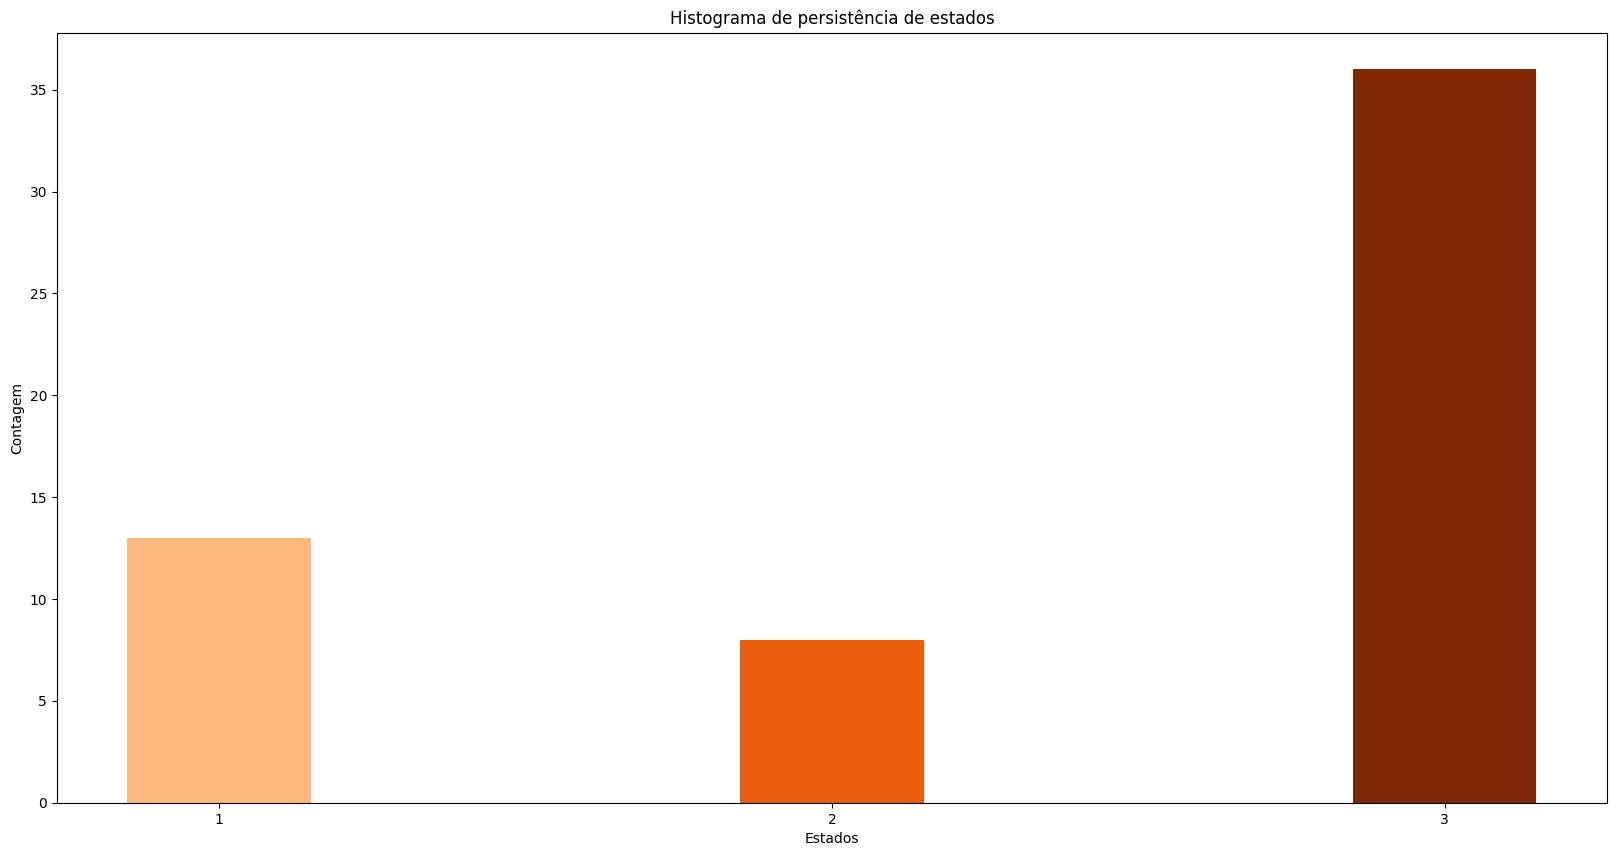

In [36]:
cmap = plt.get_cmap('Oranges', n+1)
fig,axs=plt.subplots(1,1,figsize=(20,10))
states,counts = np.unique(medianListR,return_counts=True)
axs.bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs.set_xticks(states,np.int64(states))
axs.set_ylabel("Contagem")
axs.set_xlabel("Estados")
axs.set_title("Histograma de persistência de estados")


plt.savefig("../imagens_gerais/radius_histogram_boxcox.jpg")